<a href="https://colab.research.google.com/github/ajaykumar080286/DeepLearning/blob/master/15_early_stopping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.callbacks import EarlyStopping

from mlxtend.plotting import plot_decision_regions
from matplotlib.colors import ListedColormap

from mlxtend.plotting import plot_decision_regions


In [43]:
X,y =make_circles(n_samples=180, noise=0.1,random_state=1)

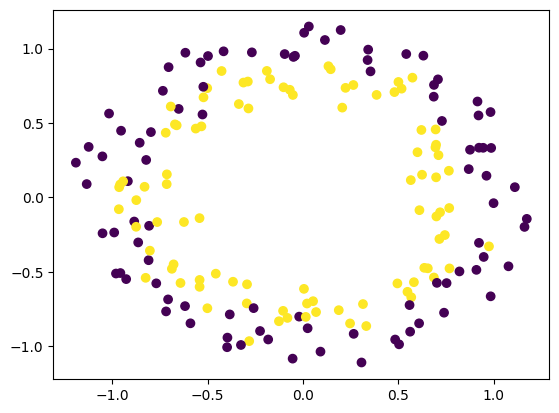

In [44]:
plt.scatter(X[:,0],X[:,1],c=y)

In [45]:
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [18]:
model=Sequential()
model.add(Dense(256,activation="relu", input_dim=2))
model.add(Dense(1,activation="sigmoid"))

In [19]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 256)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,025 (4.00 KB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(optimizer="Adam", loss="binary_crossentropy",metrics=["accuracy"])

In [32]:
#history=model.fit(X_train, y_train, validation_data=(X_test,y_test),epochs=3500)
history=model.fit(X_train, y_train, validation_data=(X_test,y_test),epochs=500)

Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9097 - loss: 0.2381 - val_accuracy: 0.8333 - val_loss: 0.4015
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9097 - loss: 0.2364 - val_accuracy: 0.8611 - val_loss: 0.4022
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9097 - loss: 0.2357 - val_accuracy: 0.8611 - val_loss: 0.4091
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9028 - loss: 0.2372 - val_accuracy: 0.8611 - val_loss: 0.4072
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9028 - loss: 0.2358 - val_accuracy: 0.8333 - val_loss: 0.3955
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9167 - loss: 0.2383 - val_accuracy: 0.8333 - val_loss: 0.3834
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9236 - loss: 0.2377 - val_accuracy: 0.8611 - val_loss: 0.3888
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9028 - loss: 0.2371 - val_accuracy: 0.8611 - val_loss:

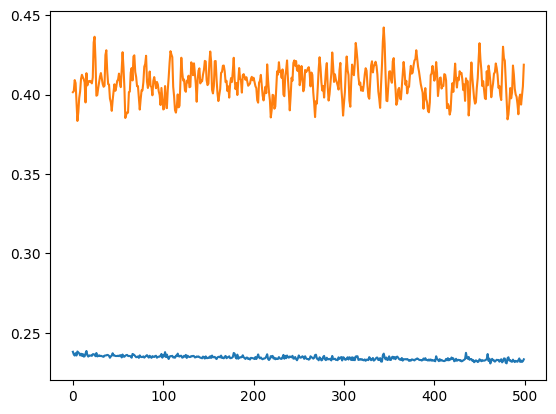

In [33]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step


<Axes: >

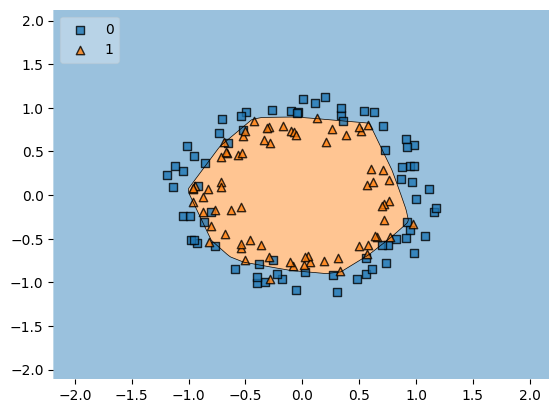

In [34]:
plot_decision_regions(X_train, y_train, clf=model,legend=2)

**Early Stopping**

In [46]:
model = Sequential()

model.add(Dense(256, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [47]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [48]:
callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0.00001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False
)

In [49]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=3500, callbacks=callback)

Epoch 1/3500
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.4583 - loss: 0.6947 - val_accuracy: 0.4444 - val_loss: 0.6910
Epoch 2/3500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5069 - loss: 0.6898 - val_accuracy: 0.4444 - val_loss: 0.6942
Epoch 3/3500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5069 - loss: 0.6876 - val_accuracy: 0.4167 - val_loss: 0.7004
Epoch 4/3500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5486 - loss: 0.6852 - val_accuracy: 0.3889 - val_loss: 0.7065
Epoch 5/3500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5625 - loss: 0.6828 - val_accuracy: 0.3889 - val_loss: 0.7114
Epoch 6/3500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5486 - loss: 0.6804 - val_accuracy: 0.3889 - val_loss: 0.7146
Epoch 7/3500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5486 - loss: 0.6799 - val_accuracy: 0.3333 - val_loss: 0.7196
Epoch 8/3500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5694 - loss: 0.6771 - val_accuracy: 0.3333 - v

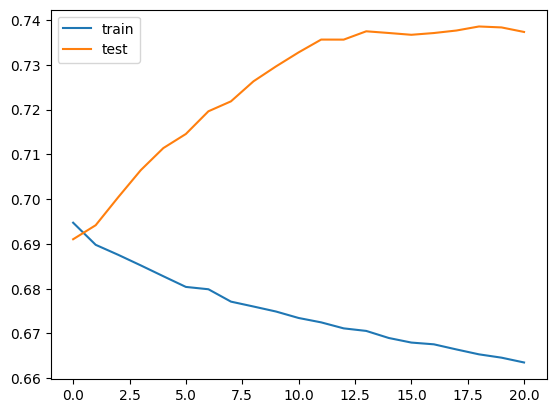

In [50]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


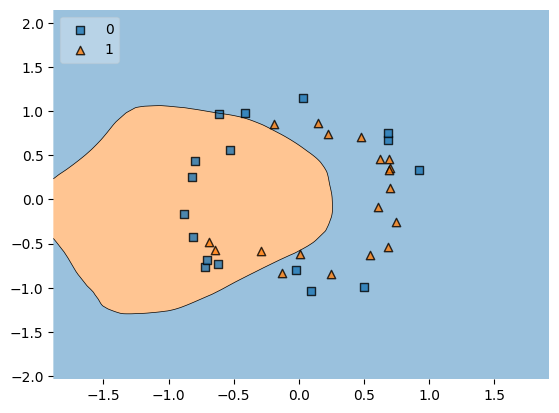

In [51]:
plot_decision_regions(X_test, y_test.ravel(), clf = model, legend=2)
plt.show()